In [12]:
!pip install transformers torch

   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 1.0/122.1 MB 3.0 MB/s eta 0:00:41
    --------------------------------------- 1.6/122.1 MB 3.2 MB/s eta 0:00:38
    --------------------------------------- 1.8/122.1 MB 2.8 MB/s eta 0:00:43
    --------------------------------------- 2.4/122.1 MB 2.6 MB/s eta 0:00:46
    --------------------------------------- 2.9/122.1 MB 2.4 MB/s eta 0:00:49
   - -------------------------------------- 3.1/122.1 MB 2.4 MB/s eta 0:00:50
   - -------------------------------------- 3.7/122.1 MB 2.3 MB/s eta 0:00:51
   - -------------------------------------- 4.2/122.1 MB 2.3 MB/s eta 0:00:52
   - -------------------------------------- 4.5/122.1 MB 2.3 MB/s eta 0:00:52
   - -------------------------------------- 5.0/122.1 MB 2.3 MB/s eta 0:00:52
   - -------------------------------------- 5.2/122.1 MB 2.2 MB/s eta 0:00:52



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from dataclasses import dataclass
from pathlib import Path


@dataclass
class CleaningConfig:
    """Cấu hình cho pipeline làm sạch dữ liệu Canifa."""
    input_jsonl_path: str = r"D:\canifa_dataset\canifa_products_wide.jsonl"
    output_dir: str = r"D:\canifa_dataset\cleaned"
    images_root: str = r"D:\canifa_dataset\images"
    train_ratio: float = 0.7
    val_ratio: float = 0.1
    test_ratio: float = 0.2
    random_seed: int = 42
    max_images_per_product: int = 3


CFG = CleaningConfig()
Path(CFG.output_dir).mkdir(parents=True, exist_ok=True)
assert abs(CFG.train_ratio + CFG.val_ratio + CFG.test_ratio - 1.0) < 1e-6, \
    "Tỷ lệ split phải cộng lại bằng 1.0"


In [4]:
# =====================================================================
# CELL 2 — ĐỌC DỮ LIỆU THÔ
# =====================================================================
import json
import logging
from typing import Any

logger = logging.getLogger("canifa_cleaning")
logging.basicConfig(level=logging.INFO)


def load_raw_records(jsonl_path: str) -> list[dict[str, Any]]:
    """Đọc toàn bộ record từ file JSONL wide-schema của Canifa.

    Args:
        jsonl_path: đường dẫn tới file .jsonl gốc.

    Returns:
        Danh sách dict, mỗi dict là 1 sản phẩm (schema "wide": 1 caption,
        nhiều field image_N_url/image_N_local_path).

    Raises:
        FileNotFoundError: nếu file không tồn tại.
    """
    records: list[dict[str, Any]] = []
    try:
        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line_num, line in enumerate(f, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError as e:
                    logger.error(f"Lỗi parse JSON ở dòng {line_num}: {e}")
    except FileNotFoundError:
        logger.error(f"Không tìm thấy file: {jsonl_path}")
        raise
    logger.info(f"Đã đọc {len(records)} bản ghi từ {jsonl_path}")
    return records


raw_records = load_raw_records(CFG.input_jsonl_path)


INFO:canifa_cleaning:Đã đọc 1883 bản ghi từ D:\canifa_dataset\canifa_products_wide.jsonl


In [5]:
# =====================================================================
# CELL 3 — CHUẨN HÓA VĂN BẢN CAPTION
# =====================================================================
import re
import unicodedata


def normalize_caption(text: str) -> str:
    """Chuẩn hóa 1 caption tiếng Việt: Unicode NFC, thêm khoảng trắng sau dấu
    câu bị dính chữ hoa (lỗi phổ biến khi crawl, vd "phong cách.Sản phẩm"),
    gộp khoảng trắng thừa, xóa khoảng trắng đầu/cuối.

    [Inferred] Lỗi "dính câu" xảy ra vì template gốc trên web nối 2 câu bằng
    dấu chấm mà không có khoảng trắng — xác nhận lại bằng cách xem vài ví dụ
    caption gốc sau khi chạy hàm này để chắc chắn không sinh lỗi ngược.
    """
    # 1) Chuẩn hóa Unicode: web có thể trả về NFC hoặc NFD lẫn lộn -> ép về NFC
    text = unicodedata.normalize("NFC", text)

    # 2) Thêm khoảng trắng sau dấu câu nếu ký tự kế tiếp là chữ cái (không phải
    #    khoảng trắng/dấu câu khác) — bắt các trường hợp dính như ".Sản phẩm"
    text = re.sub(r"([.!?,])(?=[^\s.!?,\d])", r"\1 ", text)

    # 3) Gộp nhiều khoảng trắng/xuống dòng liên tiếp thành 1 khoảng trắng
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# --- Test nhanh trên 1 caption ví dụ thực tế để xác nhận trước khi áp dụng toàn bộ ---
test_caption = ("Áo phông unisex người lớn, thiết kế dáng rộng, hình in Mickey "
                 "& Friends trẻ trung, phù hợp đa dạng phong cách.Sản phẩm kết hợp "
                 "60% cotton và 40% polyester, giúp vải xốp nhẹ, giữ phom và tăng độ bền.")
print("TRƯỚC:", test_caption)
print("SAU  :", normalize_caption(test_caption))


TRƯỚC: Áo phông unisex người lớn, thiết kế dáng rộng, hình in Mickey & Friends trẻ trung, phù hợp đa dạng phong cách.Sản phẩm kết hợp 60% cotton và 40% polyester, giúp vải xốp nhẹ, giữ phom và tăng độ bền.
SAU  : Áo phông unisex người lớn, thiết kế dáng rộng, hình in Mickey & Friends trẻ trung, phù hợp đa dạng phong cách. Sản phẩm kết hợp 60% cotton và 40% polyester, giúp vải xốp nhẹ, giữ phom và tăng độ bền.


In [6]:
# =====================================================================
# CELL 4 — DEDUP THEO CAPTION (952 caption duy nhất trong 1883 record)
# =====================================================================
from collections import defaultdict


def group_by_caption(records: list[dict[str, Any]]) -> dict[str, list[dict[str, Any]]]:
    """Nhóm các record theo caption ĐÃ CHUẨN HÓA.

    Trả về: {caption_norm: [record1, record2, ...]}
    Đây là bước then chốt để: (1) biết chính xác các caption gốc từ đâu,
    (2) sau này chia train/val/test theo NHÓM caption (tránh leakage), vì
    nhiều product_slug khác nhau (các biến thể màu/size) dùng chung 1 caption.
    """
    groups: dict[str, list[dict[str, Any]]] = defaultdict(list)
    for record in records:
        raw_caption = record.get("caption", "")
        if not raw_caption:
            logger.warning(f"Bỏ qua record thiếu caption: {record.get('product_slug')}")
            continue
        norm_caption = normalize_caption(raw_caption)
        groups[norm_caption].append(record)
    return dict(groups)


caption_groups = group_by_caption(raw_records)

group_sizes = [len(v) for v in caption_groups.values()]
print(f"Số caption duy nhất (sau chuẩn hóa): {len(caption_groups)}")
print(f"Số record trùng caption (dùng chung template): "
      f"{sum(s for s in group_sizes if s > 1)} record, "
      f"thuộc {sum(1 for s in group_sizes if s > 1)} nhóm")
print(f"Phân bố kích thước nhóm: min={min(group_sizes)}, "
      f"max={max(group_sizes)}, mean={sum(group_sizes)/len(group_sizes):.2f}")


Số caption duy nhất (sau chuẩn hóa): 952
Số record trùng caption (dùng chung template): 1394 record, thuộc 463 nhóm
Phân bố kích thước nhóm: min=1, max=8, mean=1.98



Nhóm có 8 sản phẩm:


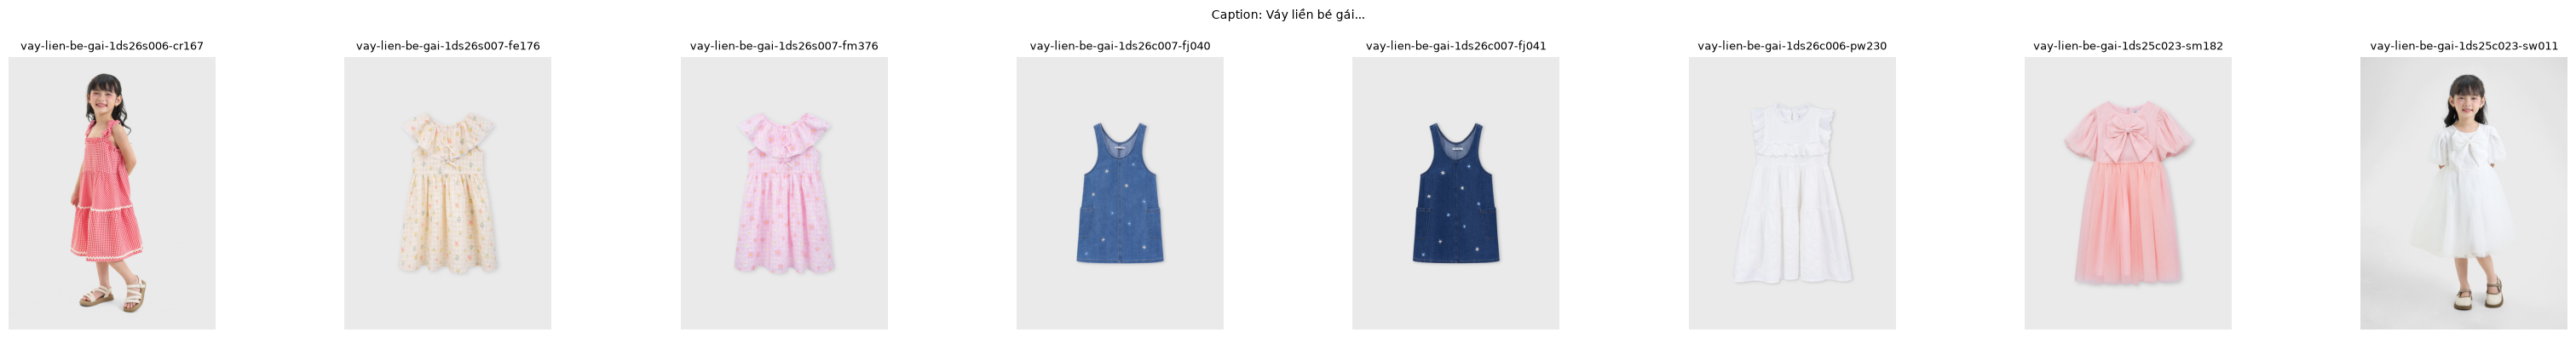


Nhóm có 8 sản phẩm:


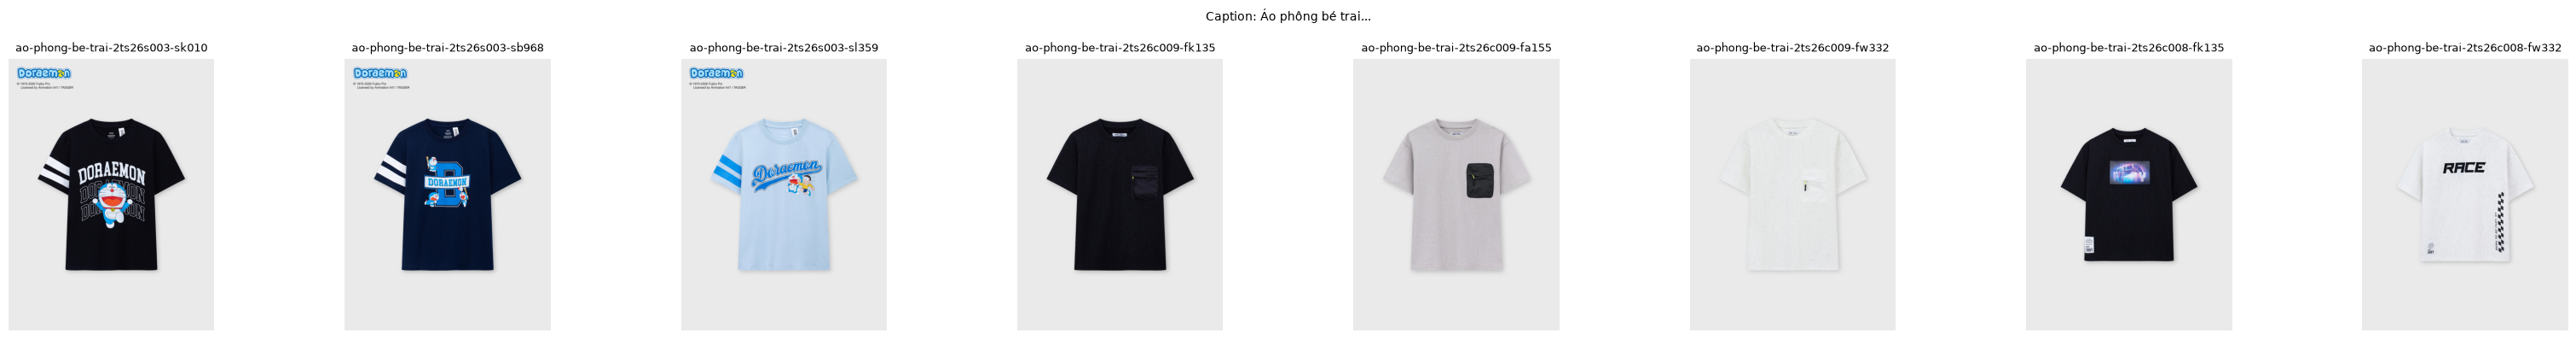


Nhóm có 7 sản phẩm:


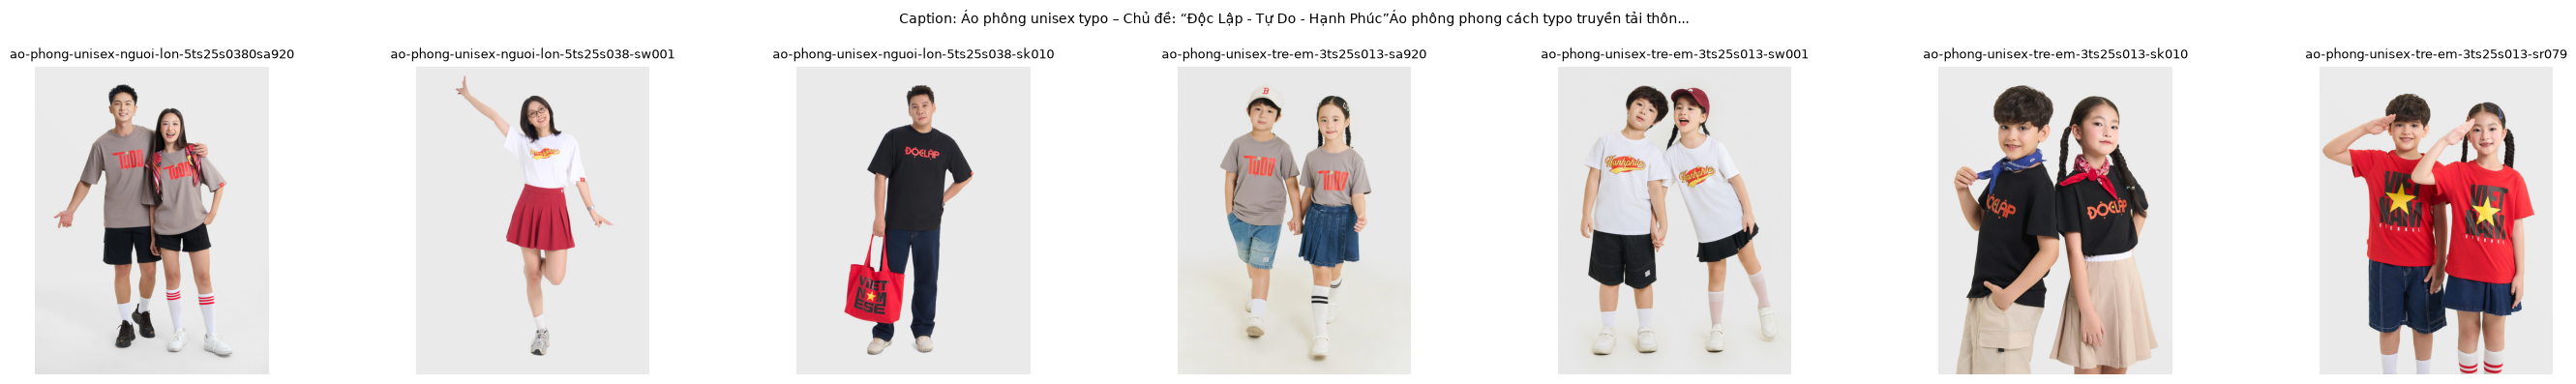

In [7]:
# =====================================================================
# CELL 4b (DEBUG) — TRỰC QUAN HÓA CÁC NHÓM CAPTION TRÙNG LỚN NHẤT
# Mục đích: kiểm chứng giả thuyết "caption trùng vì cùng sản phẩm khác
# màu/size" hay "caption trùng nhưng ảnh khác hẳn về kiểu dáng".
# =====================================================================
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError


def get_largest_groups(
    caption_groups: dict[str, list[dict]],
    top_n: int,
) -> list[tuple[str, list[dict]]]:
    """Lấy top_n nhóm có số sản phẩm nhiều nhất (để kiểm tra outlier trước).

    Args:
        caption_groups: dict {caption_norm: [record, ...]} từ Cell 4.
        top_n: số nhóm lớn nhất muốn lấy ra xem.

    Returns:
        List các tuple (caption, list_records), sắp xếp giảm dần theo size.
    """
    sorted_groups = sorted(
        caption_groups.items(), key=lambda kv: len(kv[1]), reverse=True
    )
    return sorted_groups[:top_n]


def visualize_group(
    caption: str,
    group_records: list[dict],
    max_images_per_product: int,
) -> None:
    """Hiển thị ảnh đầu tiên của MỖI sản phẩm trong 1 nhóm, cạnh nhau.

    Mỗi cột = 1 product_slug khác nhau trong cùng nhóm caption.
    Dùng để mắt thường so sánh: các sản phẩm có thực sự "giống nhau,
    chỉ khác màu/size" hay khác hẳn về kiểu dáng.
    """
    n_products = len(group_records)
    fig, axes = plt.subplots(1, n_products, figsize=(4 * n_products, 4))
    if n_products == 1:
        axes = [axes]

    for ax, record in zip(axes, group_records):
        slug = record.get("product_slug", "unknown")
        image_path = None
        for img_idx in range(1, max_images_per_product + 1):
            candidate = record.get(f"image_{img_idx}_local_path")
            if candidate:
                image_path = candidate
                break

        if image_path is None:
            ax.set_title(f"{slug}\n[Không có ảnh]", fontsize=9)
            ax.axis("off")
            continue

        try:
            img = Image.open(image_path)
            ax.imshow(img)
        except FileNotFoundError:
            logger.error(f"Không tìm thấy file ảnh: {image_path}")
            ax.set_title(f"{slug}\n[File not found]", fontsize=9)
        except UnidentifiedImageError:
            logger.error(f"File ảnh lỗi/không đọc được: {image_path}")
            ax.set_title(f"{slug}\n[Ảnh lỗi]", fontsize=9)
        else:
            ax.set_title(slug, fontsize=9)
        ax.axis("off")

    fig.suptitle(f"Caption: {caption[:100]}...", fontsize=10, wrap=True)
    plt.tight_layout()
    plt.show()


# --- Chạy thử: xem 3 nhóm lớn nhất (bao gồm nhóm max=8) ---
TOP_N_GROUPS_TO_CHECK = 3  # TODO: tăng lên nếu muốn xem thêm

largest_groups = get_largest_groups(caption_groups, TOP_N_GROUPS_TO_CHECK)
for caption, group_records in largest_groups:
    print(f"\nNhóm có {len(group_records)} sản phẩm:")
    visualize_group(caption, group_records, CFG.max_images_per_product)

In [8]:
# =====================================================================
# CELL 5 — FLATTEN WIDE -> LONG (1 dòng / 1 ảnh), GIỮ caption_group_id
#           để tránh leakage khi split, LỌC ảnh không tồn tại trên đĩa
# =====================================================================
import os


def flatten_to_long(caption_groups: dict[str, list[dict[str, Any]]],
                     max_images_per_product: int) -> list[dict[str, Any]]:
    """Chuyển schema wide (1 caption, nhiều field image_N_*) sang long
    (1 dòng = 1 ảnh), gắn caption_group_id để nhóm lại lúc chia split.

    Bỏ qua ảnh có path rỗng hoặc file không tồn tại trên đĩa.
    """
    long_rows: list[dict[str, Any]] = []
    for group_id, (caption_norm, group_records) in enumerate(caption_groups.items()):
        for record in group_records:
            product_slug = record.get("product_slug", "")
            for img_idx in range(1, max_images_per_product + 1):
                local_path = record.get(f"image_{img_idx}_local_path")
                if not local_path:
                    continue
                if not os.path.exists(local_path):
                    logger.warning(f"File ảnh không tồn tại, bỏ qua: {local_path}")
                    continue
                long_rows.append({
                    "caption_group_id": group_id,
                    "caption": caption_norm,
                    "product_slug": product_slug,
                    "category1": record.get("category1", ""),
                    "gender_category": record.get("gender_category", ""),
                    "image_path": local_path,
                })
    return long_rows


long_records = flatten_to_long(caption_groups, CFG.max_images_per_product)
print(f"Tổng số dòng ảnh sau flatten: {len(long_records)}")


Tổng số dòng ảnh sau flatten: 5640


In [9]:
# =====================================================================
# CELL 6 — CHIA TRAIN/VAL/TEST THEO caption_group_id (chống leakage)
# =====================================================================
import random


def split_by_caption_group(long_records: list[dict[str, Any]],
                            train_ratio: float, val_ratio: float,
                            seed: int) -> dict[str, list[dict[str, Any]]]:
    """Chia dữ liệu theo caption_group_id (KHÔNG theo từng dòng ảnh), đảm bảo
    toàn bộ ảnh cùng 1 caption nằm trọn trong 1 split duy nhất.
    """
    group_ids = sorted({r["caption_group_id"] for r in long_records})
    rng = random.Random(seed)
    rng.shuffle(group_ids)

    n_total = len(group_ids)
    n_train = int(n_total * train_ratio)
    n_val = int(n_total * val_ratio)

    train_ids = set(group_ids[:n_train])
    val_ids = set(group_ids[n_train:n_train + n_val])
    test_ids = set(group_ids[n_train + n_val:])

    splits: dict[str, list[dict[str, Any]]] = {"train": [], "val": [], "test": []}
    for record in long_records:
        gid = record["caption_group_id"]
        if gid in train_ids:
            splits["train"].append(record)
        elif gid in val_ids:
            splits["val"].append(record)
        else:
            splits["test"].append(record)
    return splits


splits = split_by_caption_group(long_records, CFG.train_ratio, CFG.val_ratio, CFG.random_seed)
for split_name, split_data in splits.items():
    n_groups = len({r["caption_group_id"] for r in split_data})
    print(f"{split_name}: {len(split_data)} dòng ảnh | {n_groups} caption duy nhất")


train: 3843 dòng ảnh | 666 caption duy nhất
val: 672 dòng ảnh | 95 caption duy nhất
test: 1125 dòng ảnh | 191 caption duy nhất


In [11]:
# =====================================================================
# CELL 7 — LƯU RA FILE (JSONL), sẵn sàng nạp vào notebook fine-tune Stage 2
# =====================================================================
def save_split_to_jsonl(split_data: list[dict[str, Any]], output_path: str) -> None:
    with open(output_path, "w", encoding="utf-8") as f:
        for record in split_data:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
    logger.info(f"Đã lưu {len(split_data)} dòng vào {output_path}")


for split_name, split_data in splits.items():
    out_path = os.path.join(CFG.output_dir, f"canifa_{split_name}.jsonl")
    save_split_to_jsonl(split_data, out_path)

print("\nHoàn tất làm sạch dữ liệu Canifa.")
print(f"Các file split đã lưu tại: {CFG.output_dir}")



INFO:canifa_cleaning:Đã lưu 3843 dòng vào D:\canifa_dataset\cleaned\canifa_train.jsonl
INFO:canifa_cleaning:Đã lưu 672 dòng vào D:\canifa_dataset\cleaned\canifa_val.jsonl
INFO:canifa_cleaning:Đã lưu 1125 dòng vào D:\canifa_dataset\cleaned\canifa_test.jsonl



Hoàn tất làm sạch dữ liệu Canifa.
Các file split đã lưu tại: D:\canifa_dataset\cleaned
